# Poisson Solver Testing - Extreme nonuniform Grids


## Grids Tested

**Angular grids** (fixed across all radii, shared angular mesh):

- **Uniform:**  
  Angles: $\theta_j = \frac{2\pi j}{N}, \qquad j = 0,\dots,N-1.$  

- **Pure random:**  
  Angles: $\theta_j \sim \mathcal{U}(0, 2\pi)$ drawn independently for $j = 0,\dots,N-1$, then sorted for reproducibility.  

- **Sine-clustered:**  
  Angles: $\xi_j = \frac{2\pi}{N}\left(j + \tfrac{1}{2}\right), \quad \theta_j = \xi_j + \beta \sin(k \xi_j) \pmod{2\pi}.$  
  Parameters: clustering strength $\beta$ and harmonic index $k$ (default values chosen to concentrate points near one angular band).

- **Clustered arcs:**  
  Angles: $\xi_j = \frac{2\pi}{N}\left(j + \tfrac{1}{2}\right), \quad \theta_j = \xi_j - \gamma \sin(\xi_j - \theta_0) \pmod{2\pi}.$  
  Parameters: cluster center $\theta_0$ and strength $\gamma$; default values produce strong clustering around one or two arcs.

These grids are intentionally extreme: pure random angular sampling and heavy clustering stress the frame properties of the angular Fourier system and expose failures of naïve NUFFT solvers.

## Method Suite

Four solvers:

- **FFT** (uniform grid only): standard equispaced FFT on the uniform angular mesh, exact and fastest.
- **NUDFT**: direct nonuniform DFT on the random and clustered meshes, solved via regularized least-squares, used as a high-accuracy reference where the frame is not too ill-conditioned.
- **NUFFT (Toeplitz normal-equations):** fast nonuniform transform via FINUFFT, with Fourier coefficients recovered by a Toeplitz/Block-CG solver — a fast Toeplitz operator built from FFT–KDE density weights and a T. Chan circulant preconditioner, solved via Block CG.
- **NUFFT (unsquared PCGLS):** fast nonuniform transform via FINUFFT, with Fourier coefficients recovered by an unsquared PCGLS (Pipe & Menon–style) conjugate-gradient solver on the original normal operator, avoiding spectral squaring.

Purely random angular grids and strongly clustered grids are known to be close to frame-unstable for Fourier inversion; in these stress tests, NUDFT and NUFFT may exhibit slow convergence, stagnation, or large errors

In [7]:
import os, sys
import pandas as pd
# Main project root
repo_root = r"c:\Users\charl\NUFFTRR_Poisson"
os.chdir(repo_root)
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from Tests.CPU.testing_helpers import (
    run_tests_pipeline,
    set_global_config,
    get_global_config,
    render_accuracy,
    render_runtime,
    render_table2_accuracy,
    render_table2_runtime,
    plot_accuracy_table1,
    plot_runtime_table1,
    plot_accuracy_table2,
    plot_runtime_table2,
    plot_accuracy_comparison,
    plot_runtime_comparison
)


# Setup & Configurable Parameters

In [8]:
# =============================================================================
# Domain & Solver Parameters
# =============================================================================
R = 1.0                     # Disk radius
RAD_UNIF = 1                # 1: Uniform radial grid
RADIAL_MAPPING = None       # Non-uniform radial mapping if RAD_UNIF == 0
# Solver Tolerances & Regularization (Lambda)
TOL_NUFFT = 1e-10           # CG residual tolerance for NUFFT
MAXITER_NUFFT = 100         # Maximum CG iterations (50-100 is optimal)
EPS_FINUFFT = 1e-12         # FINUFFT kernel precision (optimal W=10 width)
REG_PARAM = 1e-20           # Regularization parameter
QUAD_RULE = 1               # 1: Trapezoidal, 2: Simpson's rule
BC_CHOICE = 1               # 1: Dirichlet, 2: Neumann


# =============================================================================
# Problem Selection
# =============================================================================
PROBLEM_TYPE = 0            # 0: Borges & Daripa Problem 1, 2: Problem 2
CUSTOM_PROBLEM = None
# Apply global configuration
set_global_config(
    R=R,
    rad_unif=RAD_UNIF,
    radial_mapping=RADIAL_MAPPING,
    tol_nufft=TOL_NUFFT,
    maxiter_nufft=MAXITER_NUFFT,
    eps_finufft=EPS_FINUFFT,
    reg_param=REG_PARAM,
    quad_rule=QUAD_RULE,
    BC_choice=BC_CHOICE,
    problem_type=PROBLEM_TYPE,
    custom_problem=CUSTOM_PROBLEM,
)

# =============================================================================
# Grid Sweep Resolutions
# =============================================================================
N_vals_p1 = [32, 64, 128, 256, 512]
M_vals_p1 = [32, 64, 128, 256, 512]
N_fixed_p1 = 128


N_vals_c = [32, 64, 128, 256, 512]
M_vals_c = [32, 64, 128, 256, 512]
N_fixed_c = 128
M_fixed_c = 128

MUTE_OUTPUT = True


# Run Problems

In [9]:
# -----------------------------------------------------------------------------
# Methods for Problem 1 Single-Grid Tables (Using Pure Random Grid as the example)
# -----------------------------------------------------------------------------
METHODS_p1 = [
    dict(name="Unif-FFT", label="Uniform / FFT", azu_unif=2, mesh_kind="uniform", solver_azu_unif=2, use_nudft=None),
    dict(name="Fixed-random-NUDFT", label="Fixed random / NUDFT", azu_unif=1, mesh_kind="rand", solver_azu_unif=1, use_nudft=True),
    # Explicitly specify grid_type=2 for Toeplitz
    dict(name="Fixed-random-NUFFT-Toeplitz", label="Fixed random / NUFFT (Toeplitz)", azu_unif=1, mesh_kind="rand", solver_azu_unif=1, grid_type=2, use_nudft=False),
    # Explicitly specify grid_type=3 for Unsquared PCGLS
    dict(name="Fixed-random-NUFFT-Unsquared", label="Fixed random / NUFFT (Unsquared)", azu_unif=1, mesh_kind="rand", solver_azu_unif=1, grid_type=3, use_nudft=False),
]

METHODS_COMP = [
    dict(name="Unif-FFT", label="Uniform / FFT", azu_unif=2, mesh_kind="uniform", solver_azu_unif=2, use_nudft=None),
    dict(name="Unif-NUDFT", label="Uniform / NUDFT", azu_unif=2, mesh_kind="uniform", solver_azu_unif=1, use_nudft=True),
    
    # Explicitly split the Uniform NUFFT into Toeplitz and Unsquared
    dict(name="Unif-NUFFT-Toeplitz", label="Uniform / NUFFT (Toeplitz)", azu_unif=2, mesh_kind="uniform", solver_azu_unif=1, grid_type=2, use_nudft=False),
    dict(name="Unif-NUFFT-Unsquared", label="Uniform / NUFFT (Unsquared)", azu_unif=2, mesh_kind="uniform", solver_azu_unif=1, grid_type=3, use_nudft=False),
]
# Include rand, sine, and clustered here:
for kind in ("rand", "sine", "clustered"):
    METHODS_COMP += [
        dict(name=f"Fixed-{kind}-NUDFT", label=f"Fixed {kind} / NUDFT", azu_unif=1, mesh_kind=kind, solver_azu_unif=1, use_nudft=True),
        dict(name=f"Fixed-{kind}-NUFFT-Toeplitz", label=f"Fixed {kind} / NUFFT (Toeplitz)", azu_unif=1, mesh_kind=kind, solver_azu_unif=1, grid_type=2, use_nudft=False),
        dict(name=f"Fixed-{kind}-NUFFT-Unsquared", label=f"Fixed {kind} / NUFFT (Unsquared)", azu_unif=1, mesh_kind=kind, solver_azu_unif=1, grid_type=3, use_nudft=False),
    ]


print("\nRunning Problem 1 - Table 1 (Random Grid)...")
df_p1_t1 = run_tests_pipeline(N_vals_p1, M_vals_p1, fixed_other=None, methods=METHODS_p1, test_type="P1_Table1", mute=MUTE_OUTPUT)
print("\nRunning Problem 1 - Table 2 (Random Grid)...")
df_p1_t2 = run_tests_pipeline(None, M_vals_p1, fixed_other=N_fixed_p1, methods=METHODS_p1, test_type="P1_Table2", mute=MUTE_OUTPUT)

print("\nRunning Accuracy Comparisons...")
df_cN = run_tests_pipeline(
    N_vals_c, None,
    fixed_other=M_fixed_c,
    methods=METHODS_COMP,
    test_type="Accuracy_VaryN",
    mute=MUTE_OUTPUT,
)
df_cM = run_tests_pipeline(
    None, M_vals_c,
    fixed_other=N_fixed_c,
    methods=METHODS_COMP,
    test_type="Accuracy_VaryM",
    mute=MUTE_OUTPUT,
)
print("Done.")



Running Problem 1 - Table 1 (Random Grid)...


Pipeline (P1_Table1): 100%|██████████| 4/4 [02:08<00:00, 32.01s/it, method=Fixed-random-NUFFT-Unsquared]



Running Problem 1 - Table 2 (Random Grid)...


Pipeline (P1_Table2): 100%|██████████| 4/4 [03:09<00:00, 47.36s/it, method=Fixed-random-NUFFT-Unsquared]



Running Accuracy Comparisons...


Pipeline (Accuracy_VaryM): 100%|██████████| 13/13 [02:03<00:00,  9.50s/it, method=Fixed-clustered-NUFFT-Unsquared]

Done.


# Accuracy across Meshes

Varying N table for different grids — extreme random and clustered meshes are expected to show larger errors and slower decay with N than the uniform grid.

Accuracy Comparison (Fixed M=128) Accuracy


label,Uniform / FFT,Uniform / NUDFT,Uniform / NUFFT (Toeplitz),Uniform / NUFFT (Unsquared),Fixed clustered / NUDFT,Fixed rand / NUDFT,Fixed sine / NUDFT,Fixed clustered / NUFFT (Toeplitz),Fixed clustered / NUFFT (Unsquared),Fixed rand / NUFFT (Toeplitz),Fixed rand / NUFFT (Unsquared),Fixed sine / NUFFT (Toeplitz),Fixed sine / NUFFT (Unsquared)
N,,,,,,,,,,,,,
32,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.60e-07,6.56e-07,6.55e-07,8.12e-04,1.54e-04,1.49e-01,3.89e-02,2.34e-03,4.01e-05
64,6.55e-07,6.55e-07,6.55e-07,6.55e-07,5.34e-02,5.87e-07,6.03e-06,1.10e-03,1.83e-04,4.01e-02,7.05e-02,1.27e-03,5.08e-04
128,6.55e-07,6.55e-07,6.55e-07,6.55e-07,1.38e-01,3.80e-06,5.20e-02,1.03e-03,1.82e-04,1.23e-01,2.21e-01,6.79e-04,9.78e-05
256,6.55e-07,6.55e-07,6.55e-07,6.55e-07,2.89e-01,6.32e-02,8.21e-02,1.18e-03,1.98e-04,1.28e-01,1.74e-01,8.38e-04,9.48e-06
512,6.55e-07,6.55e-07,6.55e-07,6.55e-07,9.42e-02,1.36e-01,2.98e-02,1.32e-03,7.94e-05,2.00e-01,9.95e-01,5.82e-04,6.55e-07


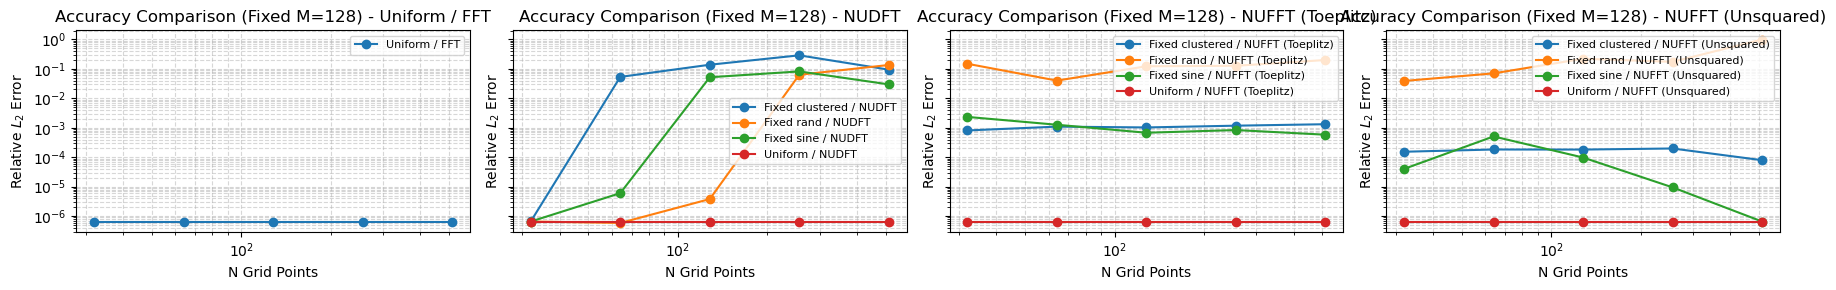

Significantly worse errors for random/clustered meshes highlight instability or inaccuracy of NUDFT/NUFFT under extreme angular sampling.
Varying M table for different grids — for stable meshes, errors should decrease as M increases; random/clustered meshes may exhibit slower decay or stagnation.

Accuracy Comparison (Fixed N=128) Accuracy


label,Uniform / FFT,Uniform / NUDFT,Uniform / NUFFT (Toeplitz),Uniform / NUFFT (Unsquared),Fixed clustered / NUDFT,Fixed rand / NUDFT,Fixed sine / NUDFT,Fixed clustered / NUFFT (Toeplitz),Fixed clustered / NUFFT (Unsquared),Fixed rand / NUFFT (Toeplitz),Fixed rand / NUFFT (Unsquared),Fixed sine / NUFFT (Toeplitz),Fixed sine / NUFFT (Unsquared)
M,,,,,,,,,,,,,
32,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.33e-01,1.16e-05,5.02e-02,1.00e-03,1.78e-04,1.23e-01,2.21e-01,6.59e-04,1.46e-04
64,2.66e-06,2.66e-06,2.66e-06,2.66e-06,1.34e-01,5.37e-06,5.14e-02,1.03e-03,1.82e-04,1.23e-01,2.21e-01,6.78e-04,9.76e-05
128,6.55e-07,6.55e-07,6.55e-07,6.55e-07,1.38e-01,3.80e-06,5.20e-02,1.03e-03,1.82e-04,1.23e-01,2.21e-01,6.79e-04,9.78e-05
256,1.62e-07,1.62e-07,1.62e-07,1.62e-07,1.61e-01,6.60e-06,5.04e-02,1.01e-03,1.82e-04,1.23e-01,2.21e-01,6.79e-04,9.78e-05
512,4.04e-08,4.04e-08,4.04e-08,4.04e-08,1.60e-01,8.98e-06,5.19e-02,1.00e-03,1.82e-04,1.23e-01,2.21e-01,6.79e-04,9.78e-05


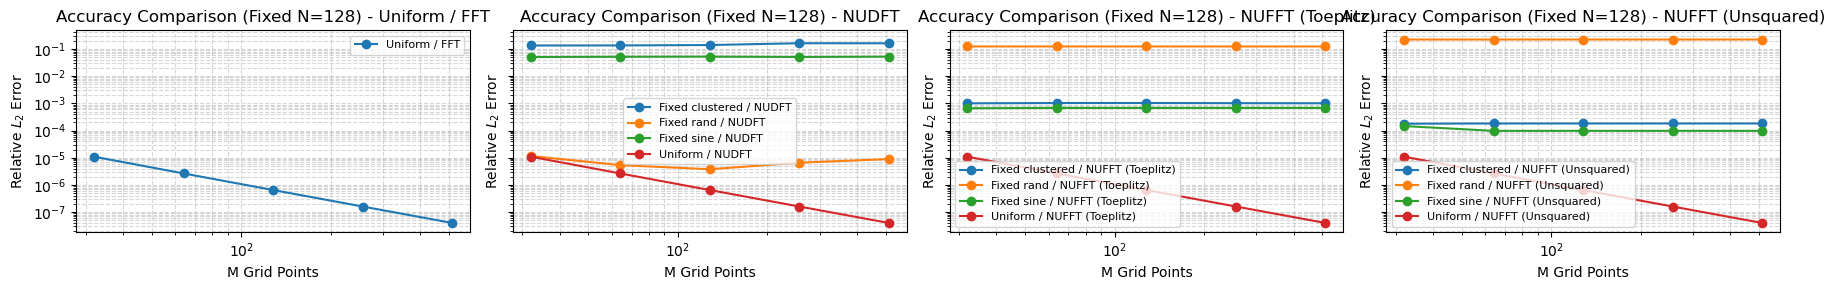

Differences between meshes indicate how sensitive each solver is to radial refinement under extreme angular grids.


In [10]:
print("Varying N table for different grids — extreme random and clustered meshes are expected to show larger errors and slower decay with N than the uniform grid.")
render_accuracy(
    df_cN,
    index_col="N",
    columns_col="label",
    title_prefix=f"Accuracy Comparison (Fixed M={M_fixed_c})"
)
plot_accuracy_comparison(
    df_cN,
    index_col="N",
    title_prefix=f"Accuracy Comparison (Fixed M={M_fixed_c})"
)
print("Significantly worse errors for random/clustered meshes highlight instability or inaccuracy of NUDFT/NUFFT under extreme angular sampling.")

print("Varying M table for different grids — for stable meshes, errors should decrease as M increases; random/clustered meshes may exhibit slower decay or stagnation.")
render_accuracy(
    df_cM,
    index_col="M",
    columns_col="label",
    title_prefix=f"Accuracy Comparison (Fixed N={N_fixed_c})"
)
plot_accuracy_comparison(
    df_cM,
    index_col="M",
    title_prefix=f"Accuracy Comparison (Fixed N={N_fixed_c})"
)
print("Differences between meshes indicate how sensitive each solver is to radial refinement under extreme angular grids.")

# Accuracy for completely random grid

Problem 1 — Table 1: Relative L2 error over angular and radial resolutions (pure random grid)

Problem 1 — Table 1 Accuracy


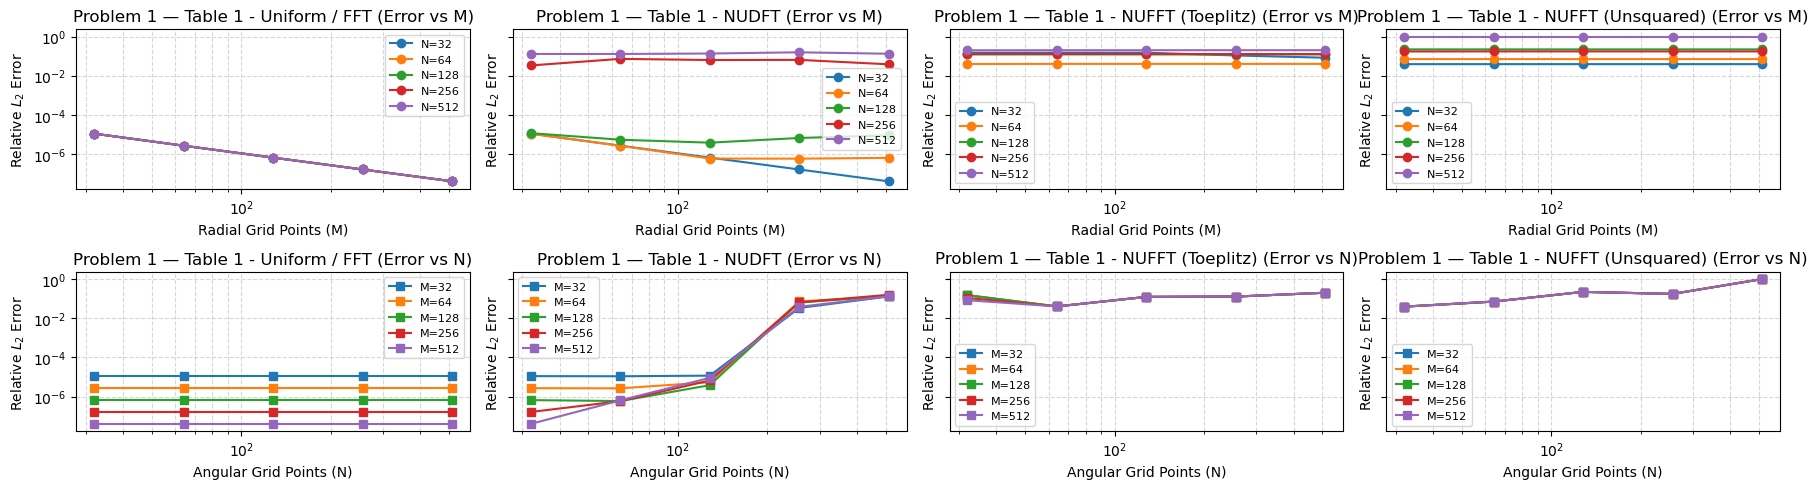

Problem 1 — Table 2: Relative L2 error by quadrature rule and boundary condition (N=128, pure random grid)

Problem 1 — Table 2 (N=128) Accuracy


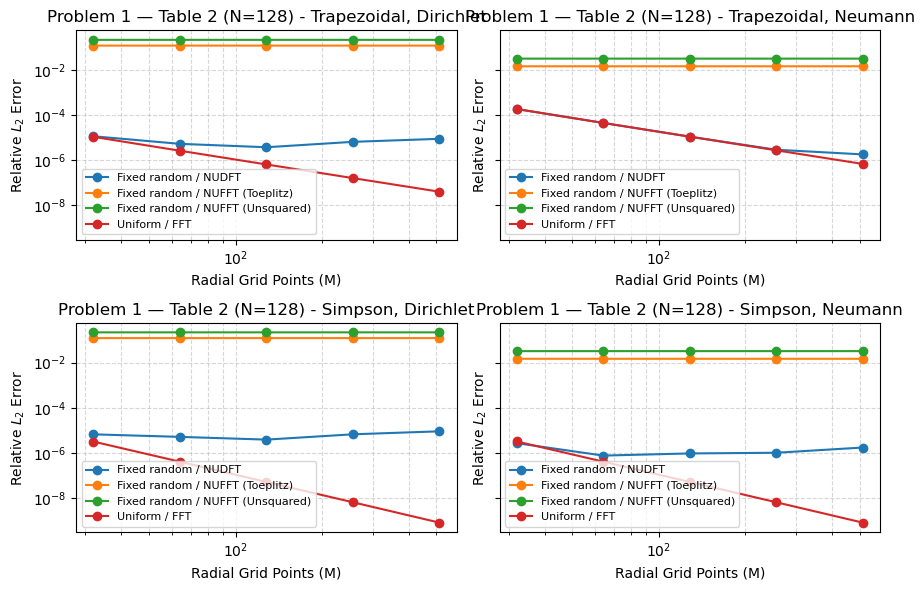

In [11]:
# Accuracy for completely random grid (Problem 1)
print("Problem 1 — Table 1: Relative L2 error over angular and radial resolutions (pure random grid)")
render_accuracy(df_p1_t1, index_col="N", columns_col=["label", "M"], title_prefix="Problem 1 — Table 1")
plot_accuracy_table1(df_p1_t1, title_prefix="Problem 1 — Table 1")

print(f"Problem 1 — Table 2: Relative L2 error by quadrature rule and boundary condition (N={N_fixed_p1}, pure random grid)")
render_table2_accuracy(df_p1_t2, title_prefix=f"Problem 1 — Table 2 (N={N_fixed_p1})")
plot_accuracy_table2(df_p1_t2, title_prefix=f"Problem 1 — Table 2 (N={N_fixed_p1})")

# Runtimes

Problem 1 — Table 1: Runtimes (pure random angular grid)

Problem 1 — Table 1 Runtime (s)


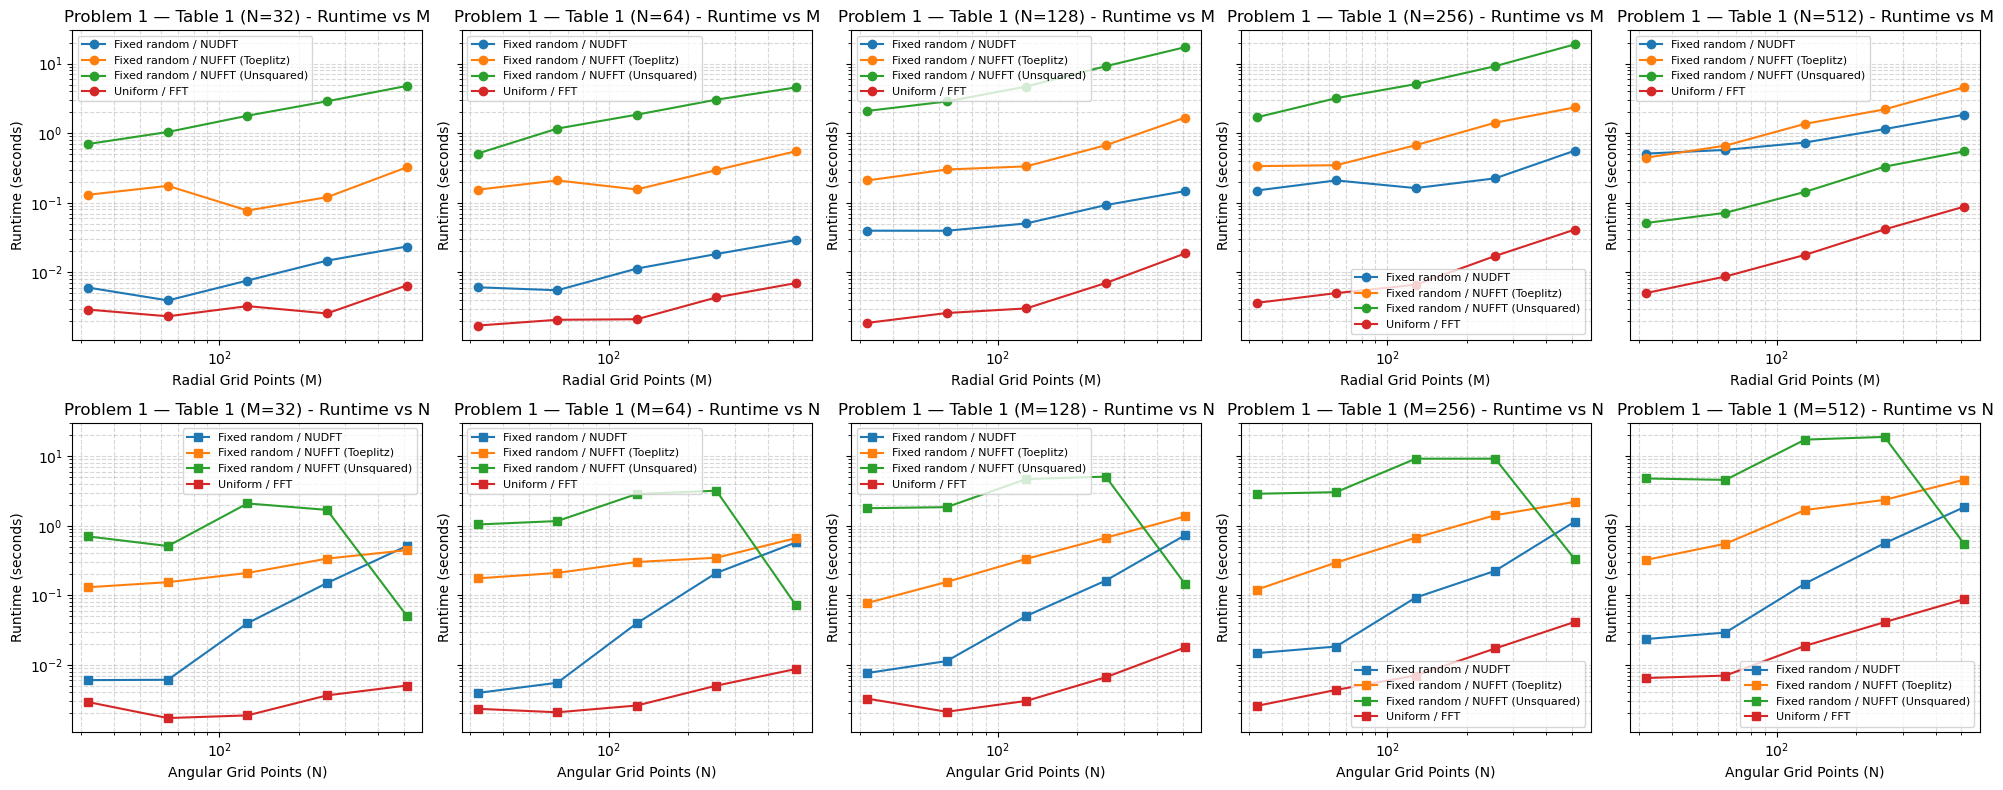

Problem 1 — Table 2: Runtimes (pure random angular grid, N=128)

Problem 1 — Table 2 (N=128) Runtime (s)


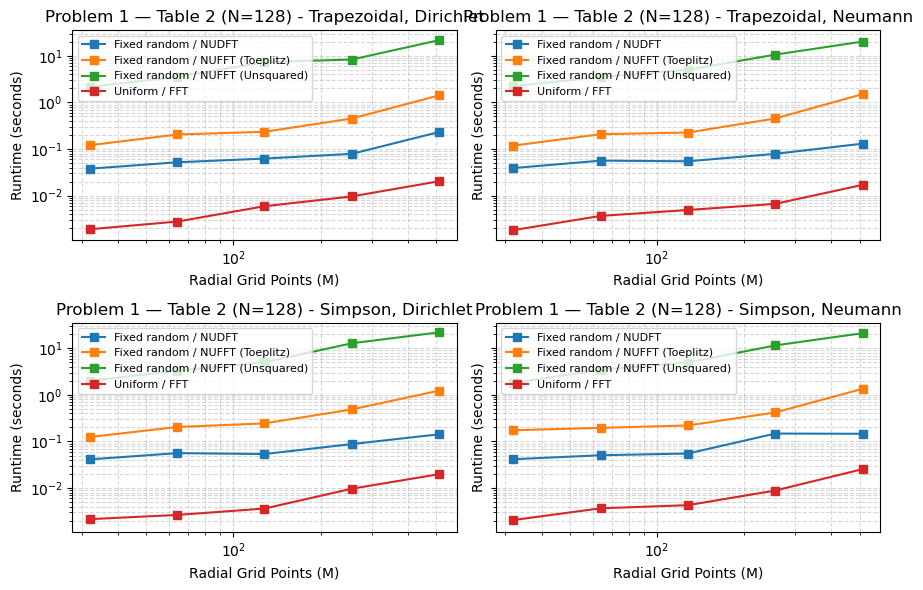

Accuracy Comparison (Fixed M=128) Runtimes

Accuracy Comparison (Fixed M=128) Runtime (s)


label,Uniform / FFT,Uniform / NUDFT,Uniform / NUFFT (Toeplitz),Uniform / NUFFT (Unsquared),Fixed clustered / NUDFT,Fixed rand / NUDFT,Fixed sine / NUDFT,Fixed clustered / NUFFT (Toeplitz),Fixed clustered / NUFFT (Unsquared),Fixed rand / NUFFT (Toeplitz),Fixed rand / NUFFT (Unsquared),Fixed sine / NUFFT (Toeplitz),Fixed sine / NUFFT (Unsquared)
N,,,,,,,,,,,,,
32,0.0044,0.0168,0.0362,0.0814,0.0190,0.0119,0.0242,0.0876,1.9412,0.1503,1.6869,0.1428,1.5976
64,0.0059,0.0163,0.0252,0.0392,0.0324,0.0210,0.0152,0.1157,1.7476,0.1568,1.7188,0.1424,0.9004
128,0.0077,0.0639,0.0565,0.0911,0.0860,0.0909,0.0731,0.4175,5.8763,0.3517,6.3311,0.3098,4.2670
256,0.0135,0.1951,0.0916,0.1169,0.2236,0.2402,0.2327,0.6912,5.1241,0.4743,6.0250,0.5194,1.0017
512,0.0334,0.6888,0.0817,0.1478,0.8003,1.2347,0.8466,1.7119,5.5583,1.3849,0.1612,1.2857,0.6922


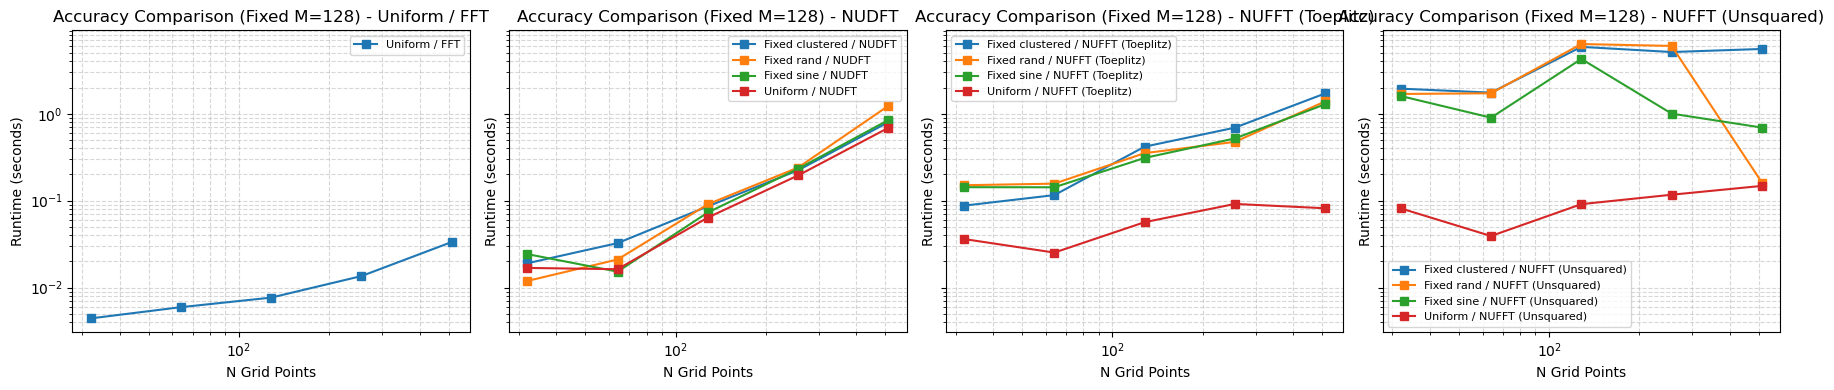

Accuracy Comparison (Fixed N=128) Runtimes

Accuracy Comparison (Fixed N=128) Runtime (s)


label,Uniform / FFT,Uniform / NUDFT,Uniform / NUFFT (Toeplitz),Uniform / NUFFT (Unsquared),Fixed clustered / NUDFT,Fixed rand / NUDFT,Fixed sine / NUDFT,Fixed clustered / NUFFT (Toeplitz),Fixed clustered / NUFFT (Unsquared),Fixed rand / NUFFT (Toeplitz),Fixed rand / NUFFT (Unsquared),Fixed sine / NUFFT (Toeplitz),Fixed sine / NUFFT (Unsquared)
M,,,,,,,,,,,,,
32,0.0039,0.0589,0.0310,0.0459,0.0661,0.0536,0.0381,0.2706,1.7760,0.1731,2.0194,0.1553,0.6305
64,0.0092,0.0504,0.0350,0.0641,0.0644,0.0575,0.0397,0.2355,2.6626,0.1988,2.7271,0.1776,2.8007
128,0.0067,0.0915,0.0552,0.0978,0.0757,0.0724,0.0500,0.2573,4.7602,0.2381,5.2729,0.2129,4.8501
256,0.0136,0.0968,0.0865,0.1762,0.0816,0.0940,0.0803,0.4752,9.0533,0.4518,8.9663,0.4154,9.1258
512,0.0317,0.1256,0.1444,0.3545,0.1806,0.1904,0.1474,1.0952,18.7778,1.2363,18.8292,1.1936,18.5044


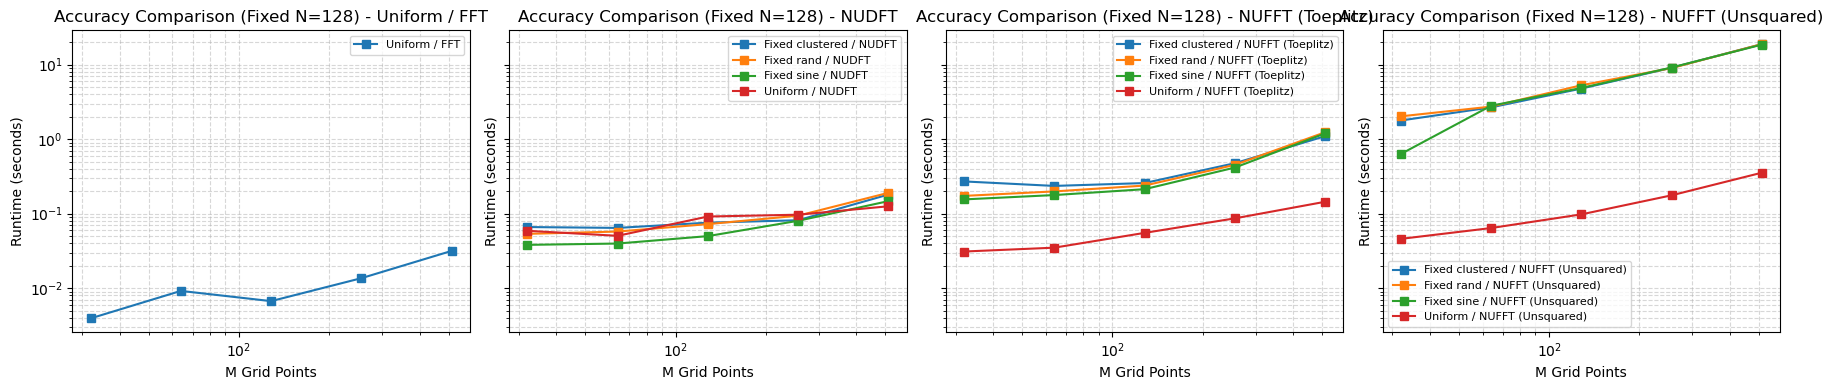

In [12]:

print("Problem 1 — Table 1: Runtimes (pure random angular grid)")
render_runtime(df_p1_t1, index_col="N", columns_col=["label", "M"], title_prefix="Problem 1 — Table 1")
plot_runtime_table1(df_p1_t1, title_prefix="Problem 1 — Table 1")

print(f"Problem 1 — Table 2: Runtimes (pure random angular grid, N={N_fixed_p1})")
render_table2_runtime(df_p1_t2, title_prefix=f"Problem 1 — Table 2 (N={N_fixed_p1})")
plot_runtime_table2(df_p1_t2, title_prefix=f"Problem 1 — Table 2 (N={N_fixed_p1})")


print(f"Accuracy Comparison (Fixed M={M_fixed_c}) Runtimes")
render_runtime(
    df_cN,
    index_col="N",
    columns_col="label",
    title_prefix=f"Accuracy Comparison (Fixed M={M_fixed_c})"
)
plot_runtime_comparison(
    df_cN,
    index_col="N",
    title_prefix=f"Accuracy Comparison (Fixed M={M_fixed_c})"
)

print(f"Accuracy Comparison (Fixed N={N_fixed_c}) Runtimes")
render_runtime(
    df_cM,
    index_col="M",
    columns_col="label",
    title_prefix=f"Accuracy Comparison (Fixed N={N_fixed_c})"
)
plot_runtime_comparison(
    df_cM,
    index_col="M",
    title_prefix=f"Accuracy Comparison (Fixed N={N_fixed_c})"
)